# 第3章 线性神经网络

本章介绍深度学习中最基础的网络结构——线性模型，包括回归与分类两大任务：

- **3.1 线性回归**：模型原理、损失函数、梯度下降、向量化
- **3.2 线性回归简洁实现**：使用 PyTorch 高层 API
- **3.3 Softmax 回归**：分类问题、网络架构、交叉熵损失
- **3.4 图像分类数据集**：Fashion-MNIST 加载与可视化
- **3.5 Softmax 回归简洁实现**：使用 PyTorch 高层 API

> 参考：[动手学深度学习 v2 · 第3章](https://zh-v2.d2l.ai/chapter_linear-networks/index.html)

In [1]:
import torch
import torch.nn as nn
from torch.utils import data
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import time

print(f'PyTorch 版本: {torch.__version__}')

PyTorch 版本: 2.8.0+cu126


---
### 3.1 线性回归

**回归**（regression）是预测连续值的任务。线性回归假设输出与输入之间存在线性关系,这里详细的推导可以参考[LinearRegression.md](../MachineLearning/3_LinearRegression/LinearRegression.md)。这里只做简单的推导和应用

**模型定义：** 给定 $d$ 维输入 $\mathbf{x} = [x_1, x_2, \ldots, x_d]^\top$，线性回归模型为：

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

其中 $\mathbf{w} \in \mathbb{R}^d$ 是权重向量，$b \in \mathbb{R}$ 是偏置标量。 对 $n$ 个样本组成的数据集，用矩阵形式表示：

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$$

其中 $\mathbf{X} \in \mathbb{R}^{n \times d}$，每行是一个样本。

**损失函数：** 衡量预测值与真实值的差距，使用**均方误差**（MSE）：

$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} \frac{1}{2}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

系数 $\frac{1}{2}$ 使导数更简洁。训练目标是求参数 $\mathbf{w}^*, b^*$ 使损失最小：

$$\mathbf{w}^*, b^* = \arg\min_{\mathbf{w}, b} L(\mathbf{w}, b)$$

**解析解：** 线性回归存在封闭形式（解析解）。将偏置 $b$ 吸收进权重（增广矩阵），得：

$$\mathbf{w}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

但大多数深度学习模型**没有**解析解，因此需要数值优化方法。

**小批量随机梯度下降（Mini-batch SGD）：** 每次从训练集随机采样一个小批量 $\mathcal{B}$，在该批量上计算梯度后更新参数：

$$\mathbf{w} \leftarrow \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \frac{\partial L^{(i)}}{\partial \mathbf{w}}$$

$$b \leftarrow b - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \frac{\partial L^{(i)}}{\partial b}$$

其中 $\eta > 0$ 为**学习率**，$|\mathcal{B}|$ 为批量大小（超参数）。

---
### 3.2 线性回归的实现

使用 PyTorch 高层 API，可以大幅简化代码。核心组件：
- `nn.Sequential`：搭建网络
- `nn.Linear`：全连接层
- `nn.MSELoss`：均方误差损失
- `torch.optim.SGD`：随机梯度下降优化器

**生成合成合成数据集**

features 形状: torch.Size([1000, 2])
labels 形状: torch.Size([1000, 1])


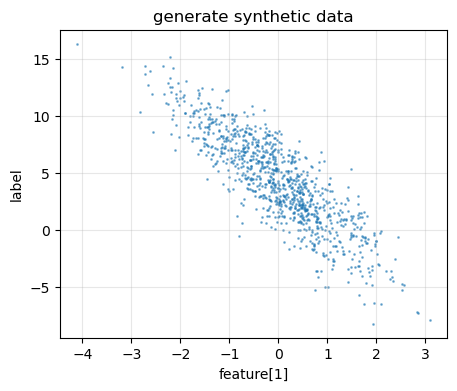

In [2]:
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声 的合成数据集"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = X @ w + b
    y += torch.normal(0, 0.01, y.shape)  # 加性高斯噪声
    return X, y.reshape(-1, 1)

# 真实参数
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

features, labels = synthetic_data(true_w, true_b, 1000)
print('features 形状:', features.shape)
print('labels 形状:', labels.shape)

# 可视化第2个特征与标签的关系
plt.figure(figsize=(5, 4))
plt.scatter(features[:, 1].numpy(), labels.numpy(), s=1, alpha=0.5)
plt.xlabel('feature[1]')
plt.ylabel('label')
plt.title('generate synthetic data')
plt.grid(True, alpha=0.3)
plt.show()

**读取数据集**

In [3]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造 PyTorch 数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size=batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

# 查看一个批量
X_batch, y_batch = next(iter(data_iter))
print('一个批量 X:', X_batch.shape)
print('一个批量 y:', y_batch.shape)

一个批量 X: torch.Size([10, 2])
一个批量 y: torch.Size([10, 1])


**定义模型**

In [4]:
# nn.Sequential 将多个层串联成一个网络
# nn.Linear(in_features, out_features) 定义全连接层
net = nn.Sequential(nn.Linear(2, 1))

print(net)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
)


**初始化模型参数**

In [5]:
# 权重初始化为均值0、标准差0.01的正态分布
net[0].weight.data.normal_(0, 0.01)
# 偏置初始化为0
net[0].bias.data.fill_(0)

print('初始权重:', net[0].weight.data)
print('初始偏置:', net[0].bias.data)

初始权重: tensor([[-0.0293, -0.0037]])
初始偏置: tensor([0.])


**定义损失函数与优化器**

In [6]:
# 均方误差损失（自动取均值）
loss_fn = nn.MSELoss()

# 小批量随机梯度下降
optimizer = torch.optim.SGD(net.parameters(), lr=0.03)

print('损失函数:', loss_fn)
print('优化器:', optimizer)

损失函数: MSELoss()
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.03
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


**训练**

In [7]:
num_epochs = 10
loss_history = []

for epoch in range(num_epochs):
    for X, y in data_iter:
        # 前向传播 + 计算损失
        l = loss_fn(net(X), y)
        # 清空上一步梯度
        optimizer.zero_grad()
        # 反向传播
        l.backward()
        # 参数更新
        optimizer.step()

    # 每轮结束后在全数据集上评估
    with torch.no_grad():
        epoch_loss = loss_fn(net(features), labels).item()
    loss_history.append(epoch_loss)
    print(f'epoch {epoch + 1:2d},  loss: {epoch_loss:.6f}')

print(f'\n真实 w: {true_w.tolist()},  估计 w: {net[0].weight.data.flatten().tolist()}')
print(f'真实 b: {true_b},  估计 b: {net[0].bias.data.item():.4f}')

epoch  1,  loss: 0.000198
epoch  2,  loss: 0.000105
epoch  3,  loss: 0.000105
epoch  4,  loss: 0.000105
epoch  5,  loss: 0.000106
epoch  6,  loss: 0.000105
epoch  7,  loss: 0.000105
epoch  8,  loss: 0.000105
epoch  9,  loss: 0.000106
epoch 10,  loss: 0.000106

真实 w: [2.0, -3.4000000953674316],  估计 w: [2.000164747238159, -3.3987345695495605]
真实 b: 4.2,  估计 b: 4.1993


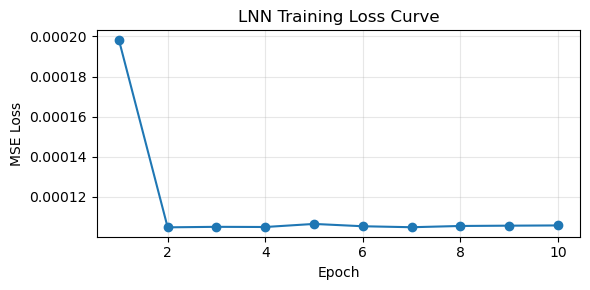

In [8]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LNN Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### 3.3 Softmax 回归

线性回归用于预测连续值；而**分类**问题需要预测离散的类别标签。
>
Softmax 回归（又称多项逻辑回归）是解决多类分类的基础模型。一般来说，Softmax 回归的输入是一个向量，表示各个样本的一个特征，输出是一个概率分布，每个类别对应一个概率。对于 $q$ 个类别，我们一般使用**独热编码**（one-hot encoding）表示标签：比如猫狗鸡三类，我们就可以表示为$(1, 0, 0)$，$(0, 1, 0)$，$(0, 0, 1)$。

这样，我们定义Softmax 回归是**单层全连接网络**，输入 $d$ 维特征，输出 $q$ 个类别的得分（logits）：

$$\mathbf{o} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

其中 $\mathbf{W} \in \mathbb{R}^{q \times d}$，$\mathbf{b} \in \mathbb{R}^q$。 参数量：$d \times q + q$（权重 + 偏置）。

**Softmax 运算**：为将输出转化为合法的概率分布（非负且和为1），使用 softmax 函数：

$$\hat{y}_j = \text{softmax}(\mathbf{o})_j = \frac{\exp(o_j)}{\sum_{k=1}^{q} \exp(o_k)}$$

预测类别为概率最大的类：$\hat{y} = \arg\max_j \hat{y}_j = \arg\max_j o_j$

这里的损失函数怎么设计呢？我们能简单地使用$1 - \hat{y}_c$吗？可以，但它有个问题——**惩罚力度不够**。比如预测正确类别的概率从 0.1 降到 0.01（差了10倍！），损失只从 0.9 变成 0.99，几乎没变化。模型感受不到"我错得更离谱了"。

**因此我们引入交叉熵损失函数。** 
用 $-\log$ 放大惩罚：可以看到 $-\log$ 的特点：- 概率接近 1 时，损失趋近 0（预测对了，几乎不惩罚）- 概率越接近 0，损失急剧增大（预测错了，严厉惩罚）

从信息论角度，交叉熵 $H(P, Q) = -\sum P(j) \log Q(j)$ 衡量的是：**用预测分布 $Q$ 去编码真实分布 $P$ 所需的平均信息量**。预测越准，需要的信息量越少，交叉熵越小。最小化交叉熵等价于让预测分布尽可能接近真实分布。


$$l(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{j=1}^{q} y_j \log \hat{y}_j$$

由于 $\mathbf{y}$ 是独热向量，只有真实类别 $y_c=1$，因此：

$$l(\mathbf{y}, \hat{\mathbf{y}}) = -\log \hat{y}_c$$

交叉熵损失对 logit $o_j$ 的梯度非常简洁：

$$\frac{\partial l}{\partial o_j} = \text{softmax}(\mathbf{o})_j - y_j$$

**信息论基础**

| 概念 | 公式 | 含义 |
|------|------|------|
| **熵** $H[P]$ | $-\sum_j P(j)\log P(j)$ | 真实分布的平均信息量（不确定性） |
| **交叉熵** $H(P,Q)$ | $-\sum_j P(j)\log Q(j)$ | 用分布 $Q$ 编码真实分布 $P$ 的平均代价 |
| **KL 散度** $D_{\text{KL}}(P\|Q)$ | $H(P,Q) - H[P]$ | 两个分布之间的距离，$\geq 0$ |

最小化交叉熵 $\Leftrightarrow$ 最小化 KL 散度 $\Leftrightarrow$ 最大化似然。

---
### 3.4 图像分类数据集（Fashion-MNIST）

Fashion-MNIST 包含 10 类服饰图片，共 60000 张训练图和 10000 张测试图，每张为 $28 \times 28$ 灰度图。

In [11]:
# 类别标签
def get_fashion_mnist_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [12]:
# 下载并加载数据集
trans = transforms.ToTensor()

mnist_train = torchvision.datasets.FashionMNIST(
    root='../data', train=True,  transform=trans, download=True)
mnist_test  = torchvision.datasets.FashionMNIST(
    root='../data', train=False, transform=trans, download=True)

print(f'训练集大小: {len(mnist_train)}')
print(f'测试集大小: {len(mnist_test)}')
print(f'单张图片形状: {mnist_train[0][0].shape}')  # (1, 28, 28)

100.0%
100.0%
100.0%
100.0%

训练集大小: 60000
测试集大小: 10000
单张图片形状: torch.Size([1, 28, 28])


In [13]:
# 构建数据加载函数（封装成工具函数）
def load_data_fashion_mnist(batch_size, resize=None):
    """加载 Fashion-MNIST 数据集，返回训练集和测试集的 DataLoader"""
    trans_list = [transforms.ToTensor()]
    if resize:
        trans_list.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans_list)

    train_set = torchvision.datasets.FashionMNIST(
        root='../data', train=True,  transform=trans, download=True)
    test_set  = torchvision.datasets.FashionMNIST(
        root='../data', train=False, transform=trans, download=True)

    # Windows 上 num_workers 建议设为 0
    train_iter = data.DataLoader(train_set, batch_size, shuffle=True,  num_workers=0)
    test_iter  = data.DataLoader(test_set,  batch_size, shuffle=False, num_workers=0)
    return train_iter, test_iter

# 测试加载速度
train_iter, test_iter = load_data_fashion_mnist(batch_size=256)
t0 = time.time()
for X, y in train_iter:
    pass
print(f'遍历训练集耗时: {time.time() - t0:.2f} s')
print(f'训练批次数: {len(train_iter)}')

遍历训练集耗时: 7.13 s
训练批次数: 235


---
### 3.5 Softmax 回归的简洁实现

使用 PyTorch 高层 API 实现 Softmax 回归对 Fashion-MNIST 进行图像分类。

**注意**：PyTorch 的 `nn.CrossEntropyLoss` 内部集成了 softmax，
直接传入 logits（未规范化预测值）即可，无需手动调用 softmax——这也能数值上更稳定。

**定义模型**

In [14]:
# nn.Flatten 将 (batch, 1, 28, 28) -> (batch, 784)
# nn.Linear(784, 10) 输出 10 个类别的 logits
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 10)
)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)

net.apply(init_weights)
print(net)
print(f'参数量: {sum(p.numel() for p in net.parameters()):,}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)
参数量: 7,850


**损失函数与优化器**

In [15]:
# CrossEntropyLoss = softmax + log + NLLLoss，数值稳定
loss_fn = nn.CrossEntropyLoss(reduction='mean')

# SGD 优化器，学习率 0.1
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

**评估函数**

In [16]:
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter):
    """计算模型在数据集上的准确率"""
    net.eval()
    correct, total = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            correct += accuracy(net(X), y)
            total   += y.numel()
    return correct / total

**训练**

In [17]:
def train_epoch(net, train_iter, loss_fn, optimizer):
    """训练一个 epoch，返回 (平均损失, 训练准确率)"""
    net.train()
    total_loss, correct, total = 0.0, 0.0, 0
    for X, y in train_iter:
        optimizer.zero_grad()
        y_hat = net(X)
        l = loss_fn(y_hat, y)
        l.backward()
        optimizer.step()
        total_loss += l.item() * y.numel()
        correct    += accuracy(y_hat, y)
        total      += y.numel()
    return total_loss / total, correct / total


num_epochs = 10
train_losses, train_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    tr_loss, tr_acc = train_epoch(net, train_iter, loss_fn, optimizer)
    te_acc = evaluate_accuracy(net, test_iter)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f'epoch {epoch+1:2d}  |  loss {tr_loss:.4f}  '
          f'|  train acc {tr_acc:.3f}  |  test acc {te_acc:.3f}')

epoch  1  |  loss 0.7874  |  train acc 0.748  |  test acc 0.768
epoch  2  |  loss 0.5702  |  train acc 0.813  |  test acc 0.797
epoch  3  |  loss 0.5251  |  train acc 0.825  |  test acc 0.812
epoch  4  |  loss 0.5008  |  train acc 0.832  |  test acc 0.824
epoch  5  |  loss 0.4856  |  train acc 0.837  |  test acc 0.821
epoch  6  |  loss 0.4734  |  train acc 0.840  |  test acc 0.809
epoch  7  |  loss 0.4663  |  train acc 0.843  |  test acc 0.822
epoch  8  |  loss 0.4580  |  train acc 0.845  |  test acc 0.833
epoch  9  |  loss 0.4524  |  train acc 0.846  |  test acc 0.827
epoch 10  |  loss 0.4471  |  train acc 0.848  |  test acc 0.831


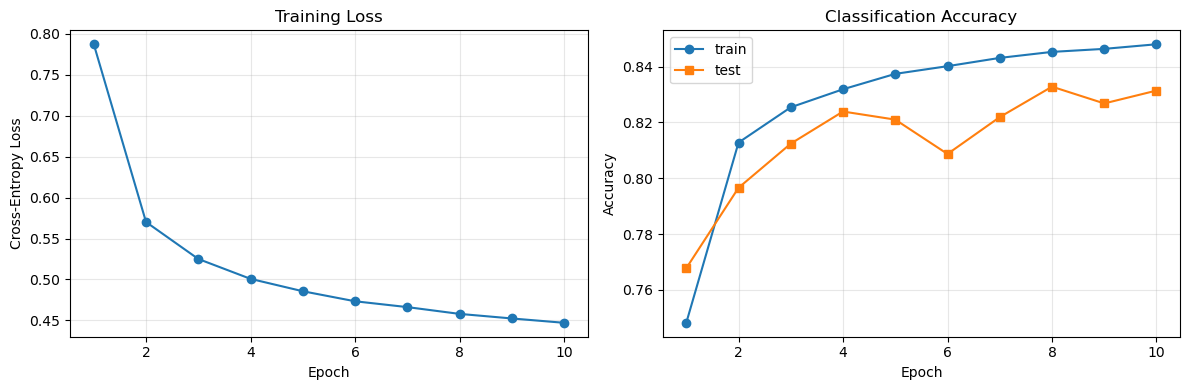

In [18]:
# 训练曲线可视化
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_accs, marker='o', label='train')
axes[1].plot(epochs, test_accs,  marker='s', label='test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Classification Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**预测结果可视化**

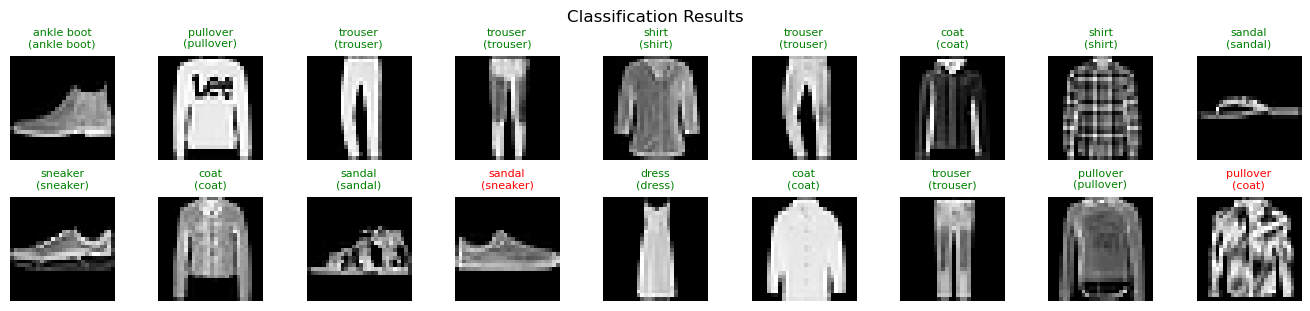

In [20]:
net.eval()
X_test, y_test = next(iter(test_iter))
with torch.no_grad():
    preds = net(X_test).argmax(dim=1)

n_show = 18
true_labels = get_fashion_mnist_labels(y_test[:n_show])
pred_labels = get_fashion_mnist_labels(preds[:n_show])

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        ax.imshow(img.squeeze(), cmap='gray')
        ax.axis('off')
        if titles:
            ax.set_title(titles[i], fontsize=8)
    plt.tight_layout()
    return fig


titles = [f'{p}\n({t})' for p, t in zip(pred_labels, true_labels)]
fig = show_images(X_test[:n_show], 2, 9, titles=titles)

# 绿色=预测正确，红色=预测错误
axes = fig.axes
for ax, p, t in zip(axes, pred_labels, true_labels):
    color = 'green' if p == t else 'red'
    ax.title.set_color(color)

plt.suptitle('Classification Results', y=1.02)
plt.show()